# Spotify Liked Songs — Comprehensive Exploratory Data Analysis

This notebook provides a full EDA of a personal Spotify \"Liked Songs\" library (~1,600 tracks). The goal is to understand the audio feature landscape, surface patterns and anomalies, and lay the analytical groundwork for clustering songs into natural playlists.

**Sections**
1. Setup & Data Loading
2. Dataset Overview
3. Descriptive Statistics
4. Feature Distributions
5. Outlier Analysis
6. Categorical Feature Analysis
7. Correlation & Multicollinearity
8. Bivariate Relationships
9. Pairplot — Key Feature Interactions
10. Skewness & Transformation Preview
11. Audio Profile Radar Chart
12. Summary & Next Steps"

---
## 1. Setup & Data Loading"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
#white background with faint horizontal grid lines behind all plots -muted palette softens default seaborn colors slightly -font scaled up 10%
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1) 

#dpi:120 renders all figures at higher resolution (sharper on screen) + font sizes set for titles and x/y axis labels
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})
COLOR_MAIN = '#1DB954'   # Spotify green
COLOR_ACC  = '#191414'   # Spotify black

# ── Load ───────────────────────────────────────────────────────────────────
df_raw = pd.read_csv('spotifyLibrary.csv', index_col=0)
df_raw['duration_min'] = df_raw['duration_ms'] / 60_000

META_COLS  = ['id', 'uri', 'track_href', 'analysis_url', 'type', 'songName']
CAT_COLS   = ['key', 'mode', 'time_signature']
CONT_COLS  = ['danceability','energy','loudness','speechiness','acousticness',
               'instrumentalness','liveness','valence','tempo','duration_min']

# Drop only columns that exist (spotifyLibrary.csv has no songName)
drop_cols = [c for c in META_COLS + ['duration_ms'] if c in df_raw.columns]
df = df_raw.drop(columns=drop_cols).reset_index(drop=True)
print(f'Loaded {df.shape[0]:,} tracks x {df.shape[1]} features')
df.head(3)


Loaded 1,573 tracks x 13 features


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_min
0,0.730,0.677,4,-7.599,0,0.3220,0.0511,0.0,0.0623,0.586,108.695,3,3.172417
1,0.801,0.688,1,-4.594,1,0.3960,0.1440,0.0,0.1070,0.500,162.928,4,2.627917
2,0.597,0.433,10,-10.280,0,0.0444,0.0762,0.0,0.1170,0.159,114.915,4,2.400000


---
## 2. Dataset Overview

Before any analysis, we audit data quality: shape, types, missing values, and duplicate tracks."

In [2]:
# ── Missing value audit ────────────────────────────────────────────────────
missing = pd.DataFrame({
    'dtype':        df.dtypes,
    'non_null':     df.notnull().sum(),
    'missing':      df.isnull().sum(),
    'missing_%':    (df.isnull().sum() / len(df) * 100).round(2),
    'unique_vals':  df.nunique()
})

print(f'Shape         : {df.shape}')
print(f'Duplicate rows: {df.duplicated().sum()}')
print()
missing.style \
    .background_gradient(subset=['missing_%'], cmap='Reds') \
    .format({'missing_%': '{:.2f}%'})

Shape         : (1573, 13)
Duplicate rows: 8



,dtype,non_null,missing,missing_%,unique_vals
danceability,float64,1573,0,0.00%,539
energy,float64,1573,0,0.00%,583
key,int64,1573,0,0.00%,12
loudness,float64,1573,0,0.00%,1426
mode,int64,1573,0,0.00%,2
speechiness,float64,1573,0,0.00%,791
acousticness,float64,1573,0,0.00%,1016
instrumentalness,float64,1573,0,0.00%,790
liveness,float64,1573,0,0.00%,635
valence,float64,1573,0,0.00%,749


---
## 3. Descriptive Statistics

Summary stats for all continuous features. Pay attention to the gap between mean and median (skew signal) and the spread between min/max (outlier signal)."

In [3]:
desc = df[CONT_COLS].describe().T
desc['skewness'] = df[CONT_COLS].skew().round(3)
desc['kurtosis'] = df[CONT_COLS].apply(kurtosis).round(3)
desc['cv_%']     = (df[CONT_COLS].std() / df[CONT_COLS].mean() * 100).round(1)

desc.style \
    .background_gradient(subset=['skewness'], cmap='RdYlGn_r', vmin=-3, vmax=3) \
    .background_gradient(subset=['cv_%'], cmap='Blues') \
    .format(precision=3)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,cv_%
danceability,1573.000,0.694,0.146,0.157,0.598,0.708,0.805,0.980,-0.439,-0.244,21.000
energy,1573.000,0.636,0.160,0.109,0.530,0.636,0.750,0.994,-0.135,-0.337,25.100
loudness,1573.000,-6.848,2.436,-21.447,-8.151,-6.568,-5.199,-0.283,-0.935,2.233,-35.600
speechiness,1573.000,0.160,0.132,0.024,0.052,0.108,0.251,0.855,1.150,0.972,82.200
acousticness,1573.000,0.173,0.197,0.000,0.025,0.093,0.258,0.944,1.466,1.524,113.800
instrumentalness,1573.000,0.046,0.158,0.000,0.000,0.000,0.001,0.973,3.974,15.361,341.000
liveness,1573.000,0.190,0.141,0.016,0.101,0.134,0.238,0.966,1.994,4.505,74.300
valence,1573.000,0.440,0.223,0.027,0.265,0.418,0.600,0.980,0.309,-0.692,50.700
tempo,1573.000,124.787,27.394,55.679,103.951,125.995,142.972,215.593,0.055,-0.392,22.000
duration_min,1573.000,3.654,0.955,0.927,3.103,3.560,4.103,19.103,3.532,45.961,26.100


---
## 4. Feature Distributions

Histograms with KDE overlays reveal shape, modality, and tail behaviour for each audio feature. Features that are bimodal or heavily skewed will need transformation before clustering."

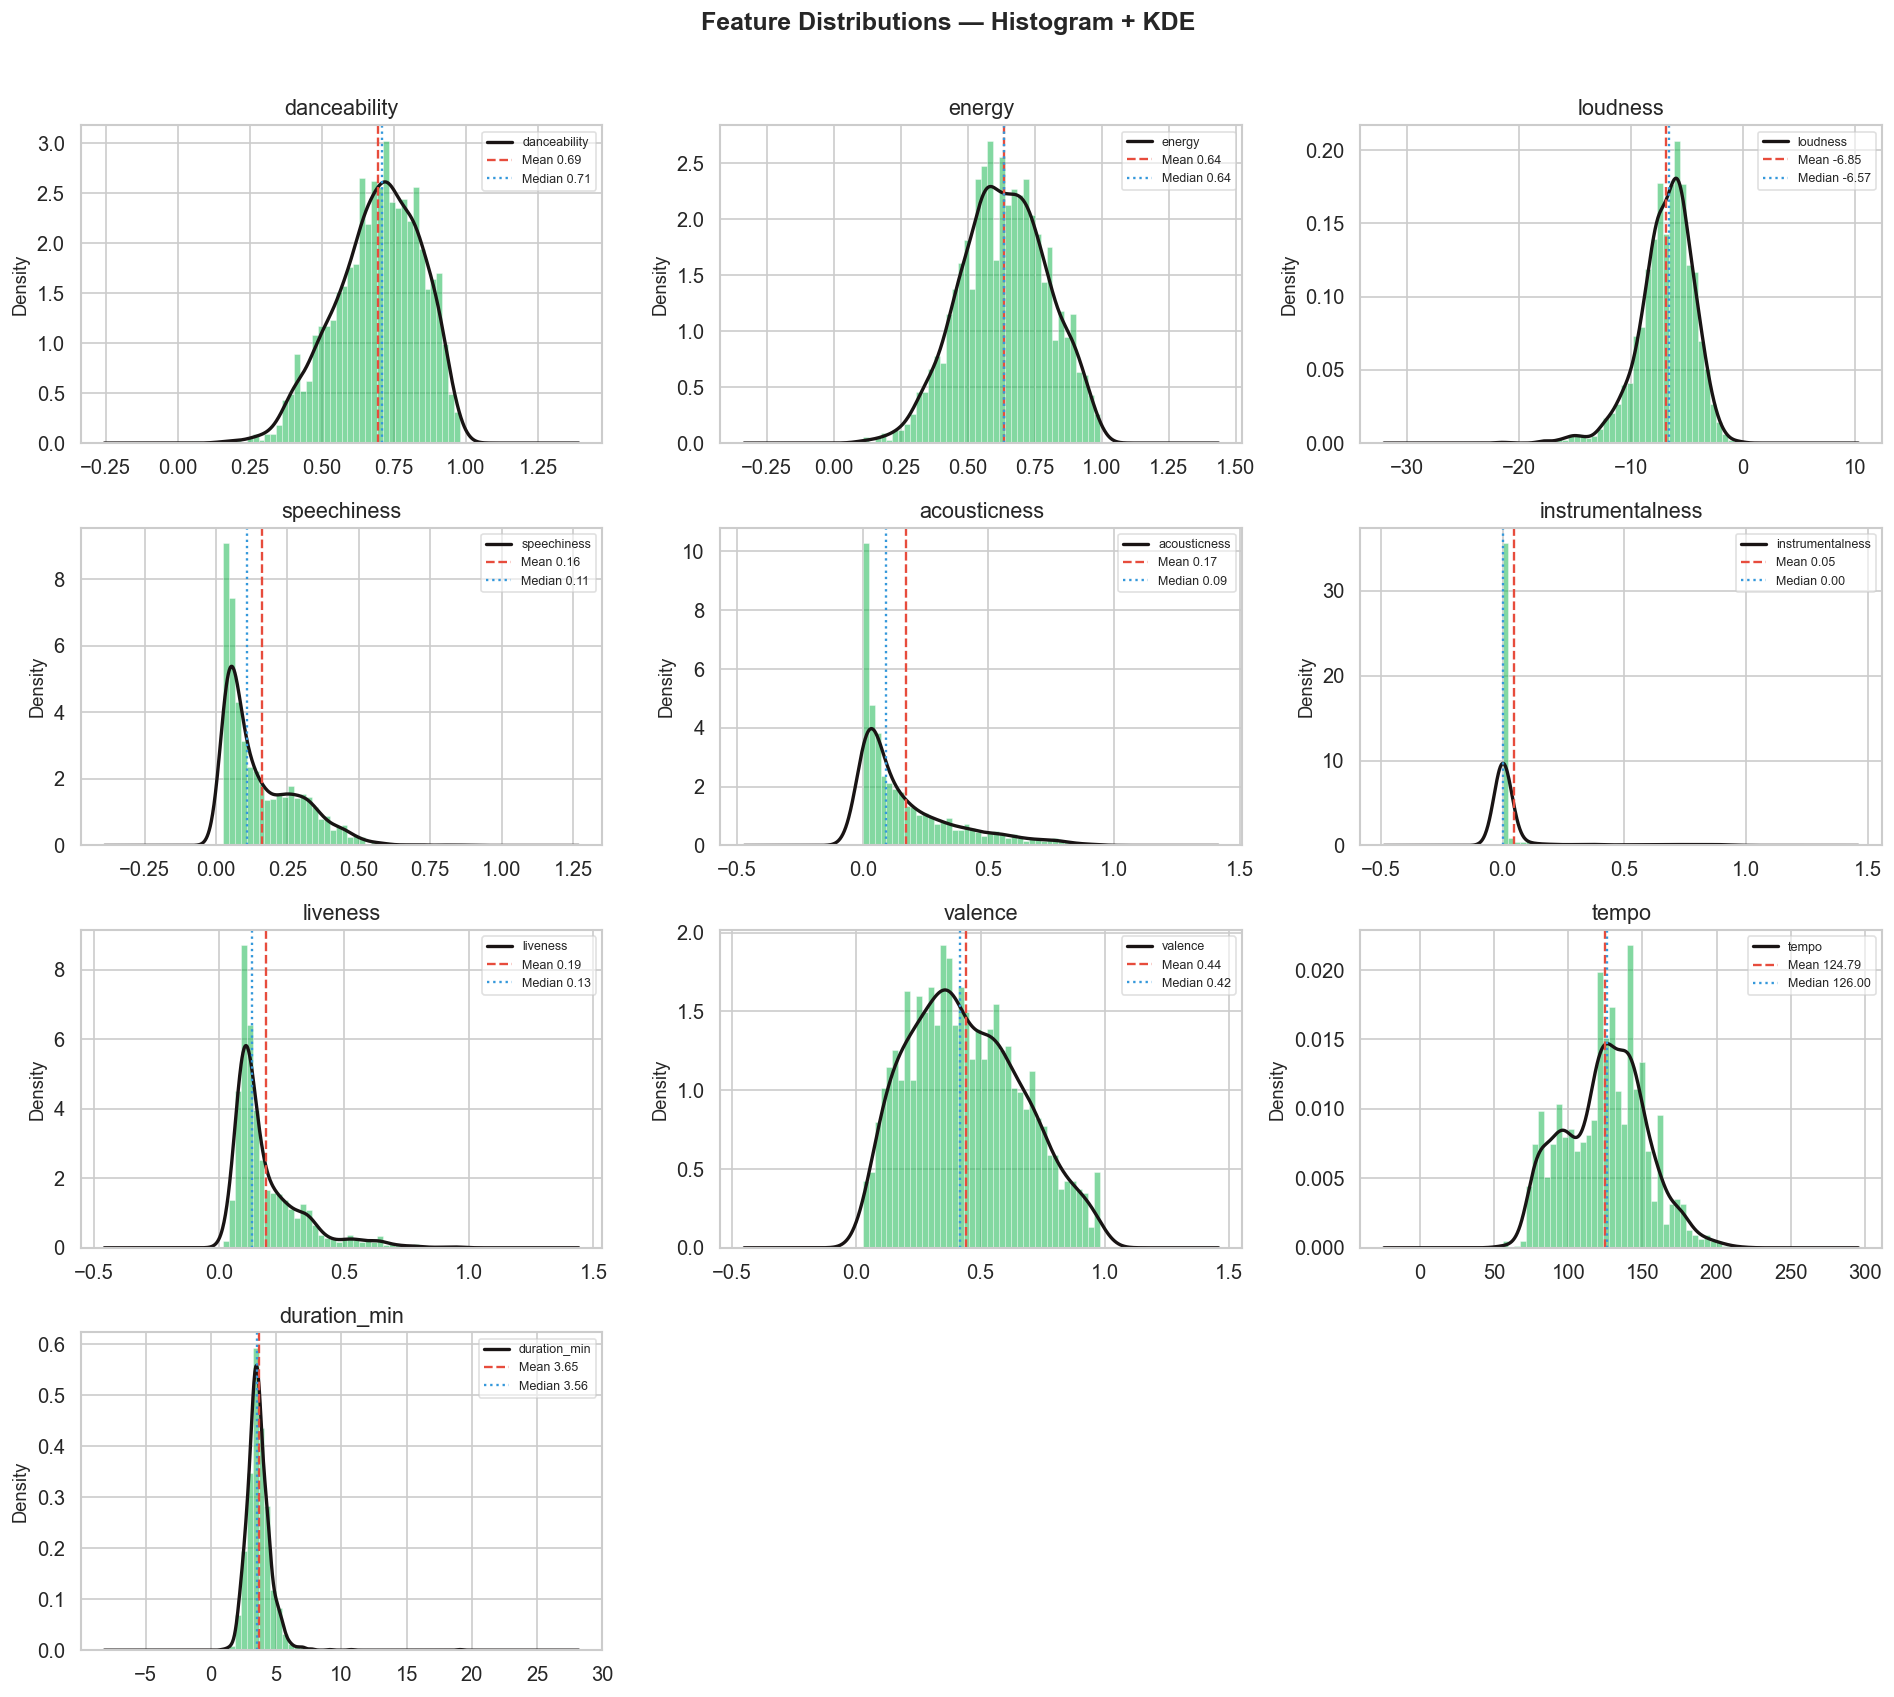

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(CONT_COLS):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=40, color=COLOR_MAIN, alpha=0.55, density=True, edgecolor='white', linewidth=0.4)
    data.plot.kde(ax=ax, color=COLOR_ACC, linewidth=2)
    ax.axvline(data.mean(),   color='#e74c3c', linestyle='--', linewidth=1.4, label=f'Mean {data.mean():.2f}')
    ax.axvline(data.median(), color='#3498db', linestyle=':',  linewidth=1.4, label=f'Median {data.median():.2f}')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.legend(fontsize=7.5, framealpha=0.6)
    ax.set_ylabel('Density')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions — Histogram + KDE', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

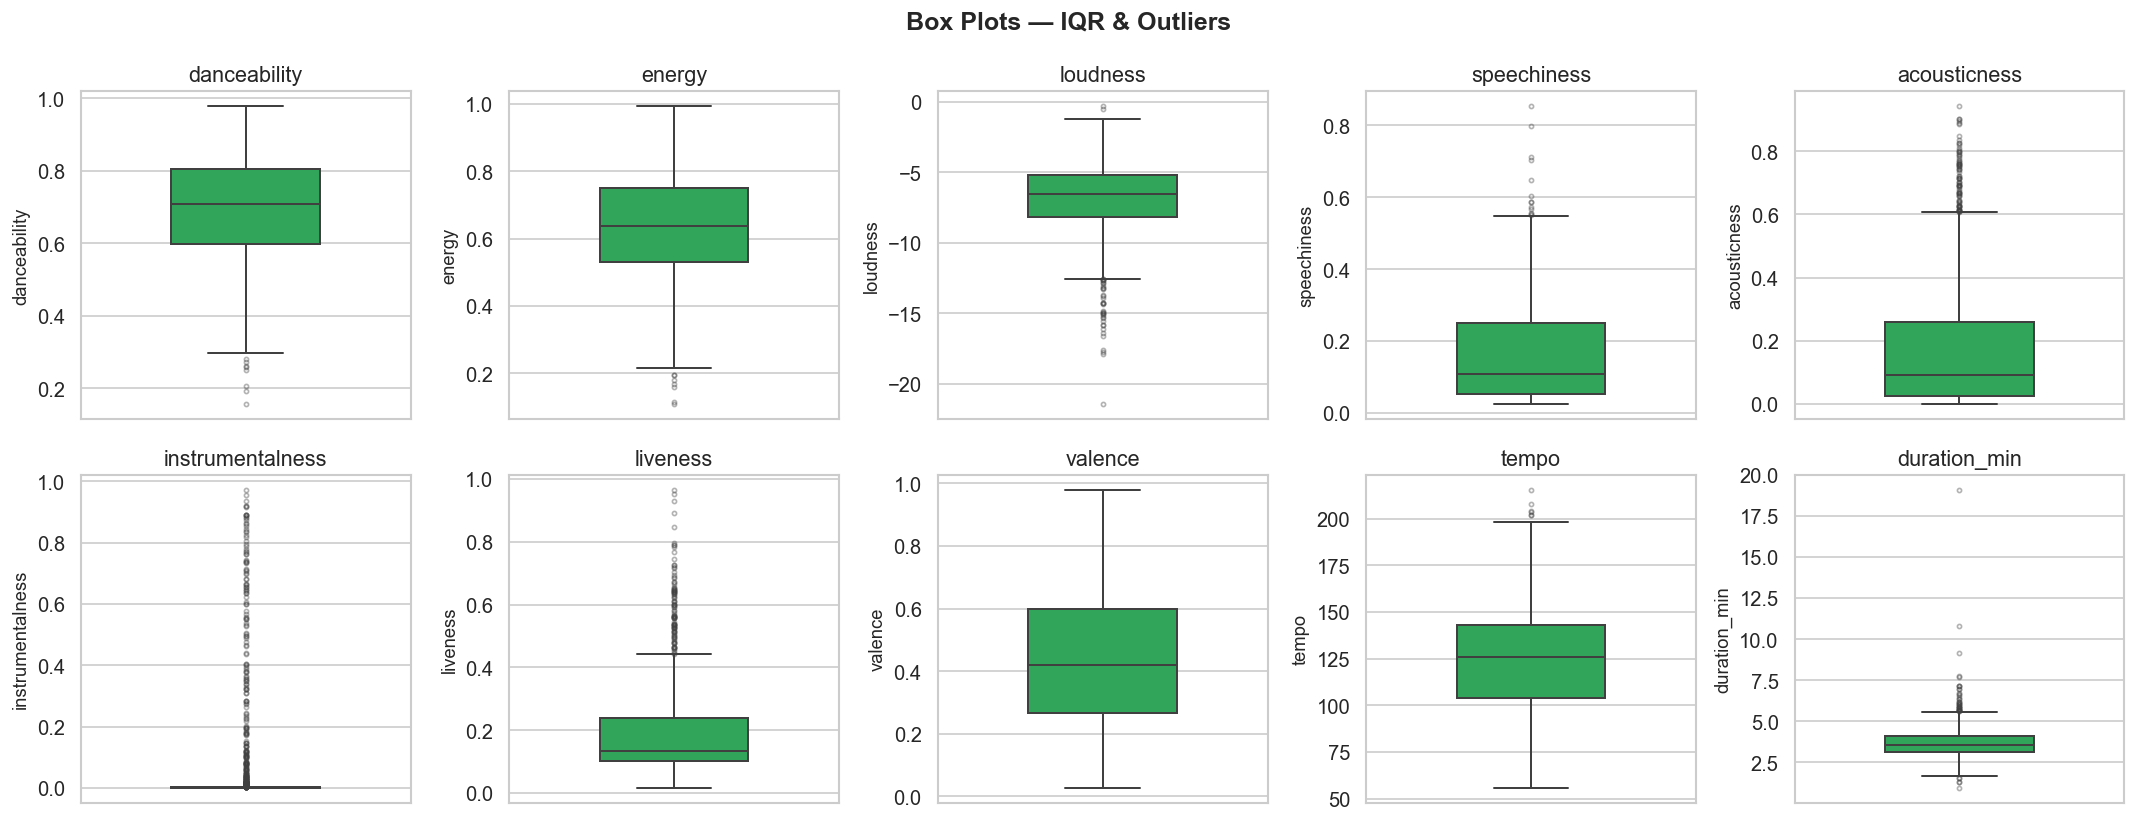

In [5]:
# ── Box plots — same features, shows IQR and outlier dots side-by-side ─────
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(CONT_COLS):
    ax = axes[i]
    sns.boxplot(y=df[col], ax=ax, color=COLOR_MAIN,
                flierprops=dict(marker='o', markersize=2.5, alpha=0.4, color='#e74c3c'),
                width=0.45, linewidth=1.2)
    ax.set_title(col)
    ax.set_xlabel('')

fig.suptitle('Box Plots — IQR & Outliers', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Outlier Analysis

Using the IQR fence method (1.5×IQR) to quantify extreme values per feature. High outlier counts flag features that will distort distance-based clustering."

In [6]:
rows = []
for col in CONT_COLS:
    s   = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((s < lo) | (s > hi)).sum()
    rows.append({'feature': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                 'lower_fence': lo, 'upper_fence': hi,
                 'n_outliers': n_out, 'outlier_%': round(n_out / len(s) * 100, 2)})

outlier_df = pd.DataFrame(rows).set_index('feature')
outlier_df.style \
    .background_gradient(subset=['outlier_%'], cmap='OrRd') \
    .format({'Q1': '{:.3f}', 'Q3': '{:.3f}', 'IQR': '{:.3f}',
             'lower_fence': '{:.3f}', 'upper_fence': '{:.3f}', 'outlier_%': '{:.2f}%'})

,Q1,Q3,IQR,lower_fence,upper_fence,n_outliers,outlier_%
feature,,,,,,,
danceability,0.598,0.805,0.207,0.287,1.116,8,0.51%
energy,0.530,0.750,0.220,0.200,1.080,7,0.45%
loudness,-8.151,-5.199,2.952,-12.579,-0.771,38,2.42%
speechiness,0.052,0.251,0.199,-0.247,0.550,13,0.83%
acousticness,0.025,0.258,0.234,-0.326,0.608,80,5.09%
instrumentalness,0.000,0.001,0.001,-0.002,0.004,331,21.04%
liveness,0.101,0.238,0.137,-0.104,0.443,100,6.36%
valence,0.265,0.600,0.335,-0.237,1.103,0,0.00%
tempo,103.951,142.972,39.021,45.419,201.504,6,0.38%


---
## 6. Categorical Feature Analysis

`key`, `mode`, and `time_signature` are discrete labels, not ordinal numbers. Treating them as continuous in clustering would be a methodological error."

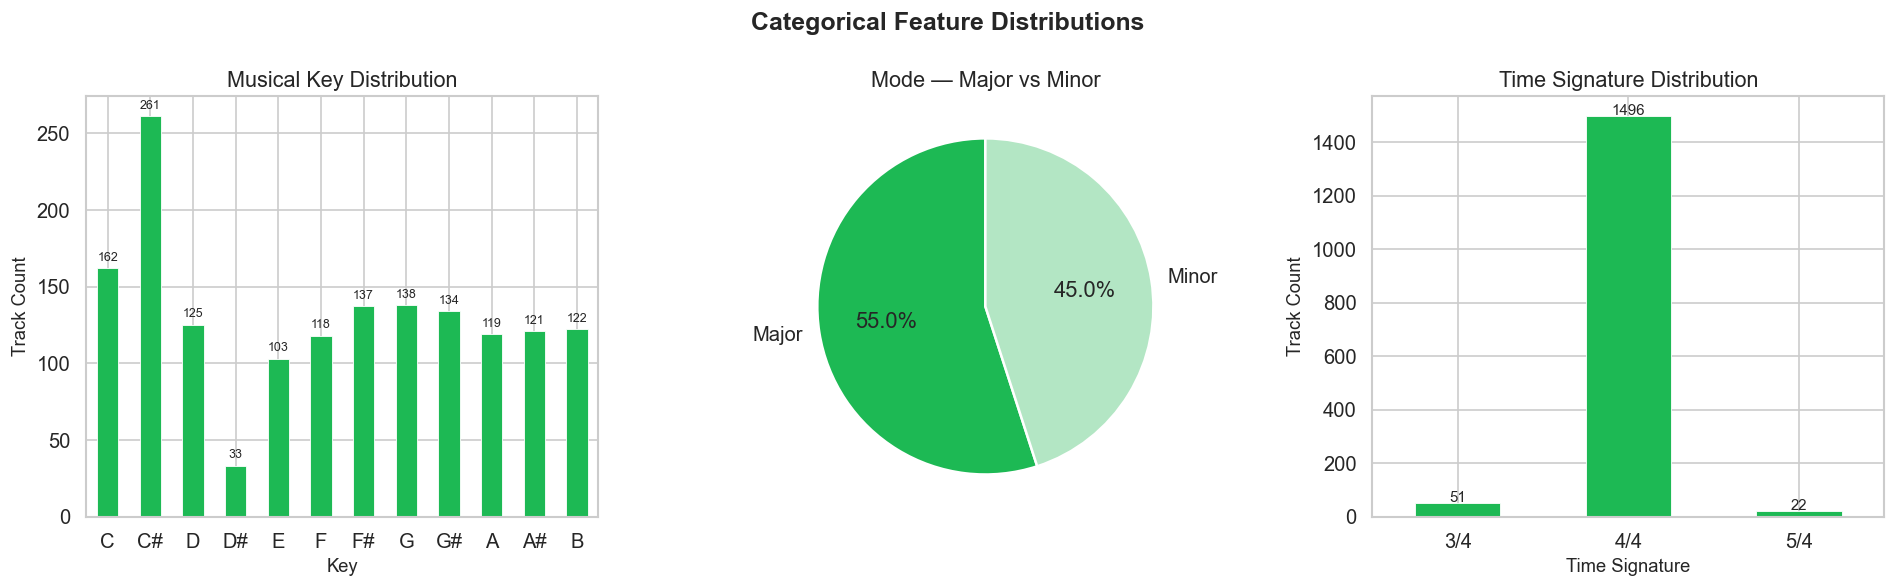

In [7]:
KEY_LABELS = {0:'C',1:'C#',2:'D',3:'D#',4:'E',5:'F',
               6:'F#',7:'G',8:'G#',9:'A',10:'A#',11:'B'}
MODE_LABELS = {0: 'Minor', 1: 'Major'}
TIME_LABELS = {3: '3/4', 4: '4/4', 5: '5/4'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Key distribution
key_counts = df['key'].map(KEY_LABELS).value_counts().reindex(KEY_LABELS.values())
key_counts.plot.bar(ax=axes[0], color=COLOR_MAIN, edgecolor='white', linewidth=0.5)
axes[0].set_title('Musical Key Distribution')
axes[0].set_xlabel('Key')
axes[0].set_ylabel('Track Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height() + 5),
                     ha='center', fontsize=7.5)

# Mode distribution
mode_counts = df['mode'].map(MODE_LABELS).value_counts()
axes[1].pie(mode_counts, labels=mode_counts.index, autopct='%1.1f%%',
            colors=[COLOR_MAIN, '#b3e6c4'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Mode — Major vs Minor')

# Time signature
ts_counts = df['time_signature'].map(TIME_LABELS).value_counts().sort_index()
ts_counts.plot.bar(ax=axes[2], color=COLOR_MAIN, edgecolor='white', linewidth=0.5)
axes[2].set_title('Time Signature Distribution')
axes[2].set_xlabel('Time Signature')
axes[2].set_ylabel('Track Count')
axes[2].tick_params(axis='x', rotation=0)
for p in axes[2].patches:
    axes[2].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height() + 5),
                     ha='center', fontsize=9)

plt.suptitle('Categorical Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

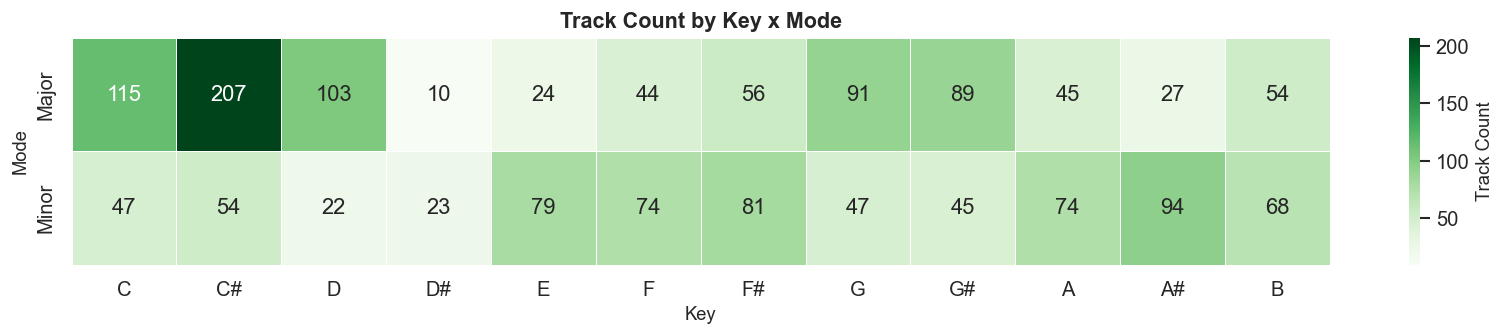

In [8]:
# ── Mode x Key crosstab heatmap ────────────────────────────────────────────
ct_df = df.copy()
ct_df['key_label']  = ct_df['key'].map(KEY_LABELS)
ct_df['mode_label'] = ct_df['mode'].map(MODE_LABELS)
ct_df = ct_df.dropna(subset=['key_label', 'mode_label'])

crosstab = pd.crosstab(ct_df['mode_label'], ct_df['key_label'])
# Add any missing keys as zero columns
for k in KEY_LABELS.values():
    if k not in crosstab.columns:
        crosstab[k] = 0
crosstab = crosstab[list(KEY_LABELS.values())]

fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Greens', linewidths=0.4,
            linecolor='white', ax=ax, cbar_kws={'label': 'Track Count'})
ax.set_title('Track Count by Key x Mode', fontsize=13, fontweight='bold')
ax.set_xlabel('Key')
ax.set_ylabel('Mode')
plt.tight_layout()
plt.show()


---
## 7. Correlation & Multicollinearity

Strong correlations between features are a problem for K-Means (collinear dimensions are double-counted) and a signal for PCA-based dimensionality reduction."

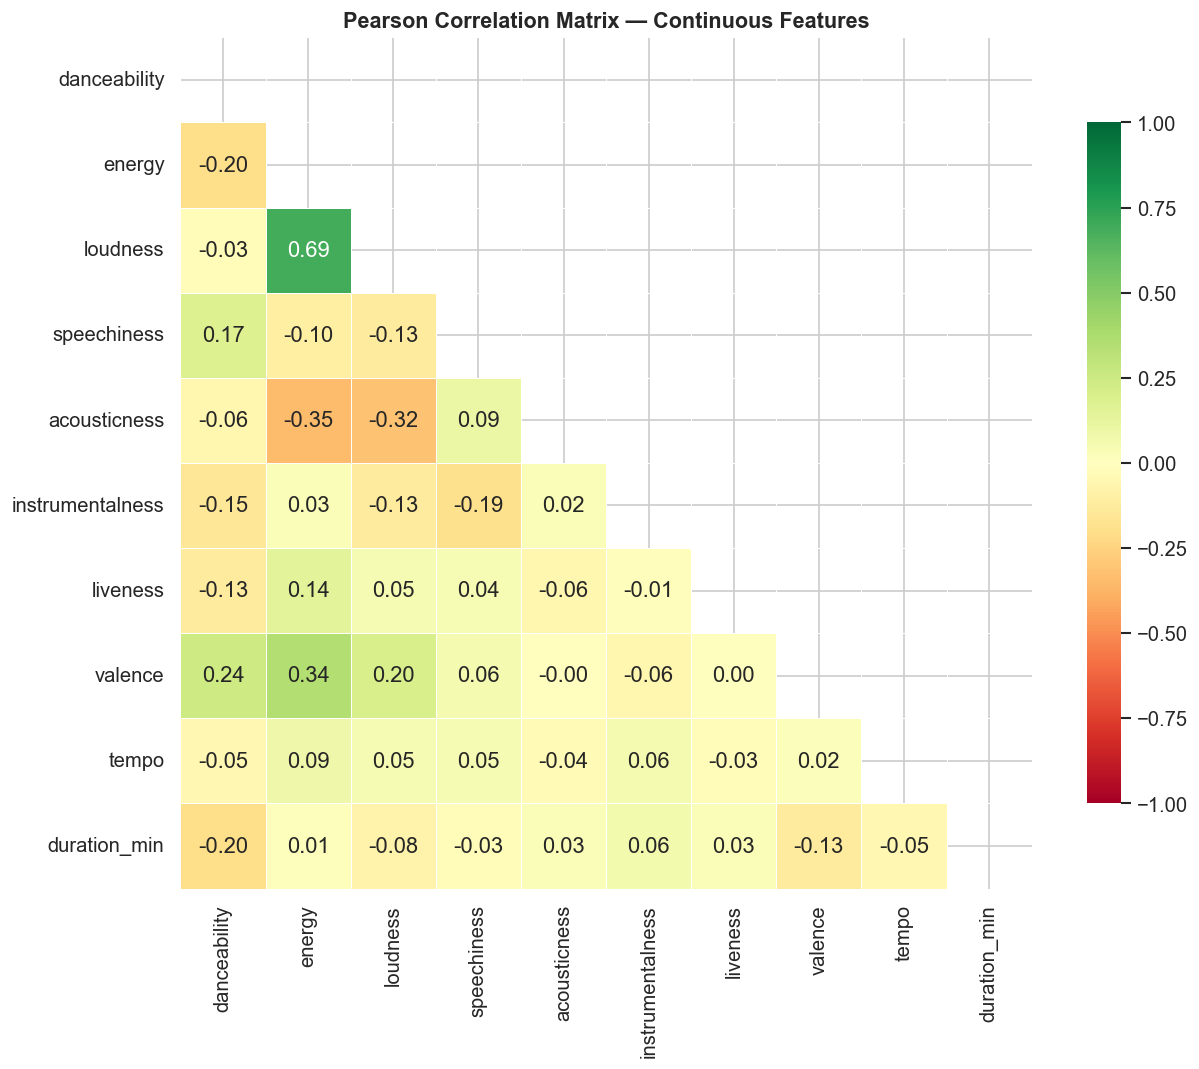

In [9]:
corr = df[CONT_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5,
            linecolor='white', ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Pearson Correlation Matrix — Continuous Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ── Top 10 strongest correlations (absolute value) ─────────────────────────
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ['feature_a', 'feature_b', 'correlation']
top_corr = corr_pairs.reindex(corr_pairs['correlation'].abs().sort_values(ascending=False).index).head(10)

top_corr.style \
    .background_gradient(subset=['correlation'], cmap='RdYlGn', vmin=-1, vmax=1) \
    .format({'correlation': '{:.4f}'})

,feature_a,feature_b,correlation
21,loudness,energy,0.6893
41,acousticness,energy,-0.3486
71,valence,energy,0.3439
42,acousticness,loudness,-0.3163
70,valence,danceability,0.2442
72,valence,loudness,0.2008
10,energy,danceability,-0.1960
90,duration_min,danceability,-0.1959
53,instrumentalness,speechiness,-0.1937
30,speechiness,danceability,0.1747


---
## 8. Bivariate Relationships

Scatter plots of the highest-signal feature pairs — coloured by `mode` so we can see if musical key/mode drives the observed clusters."

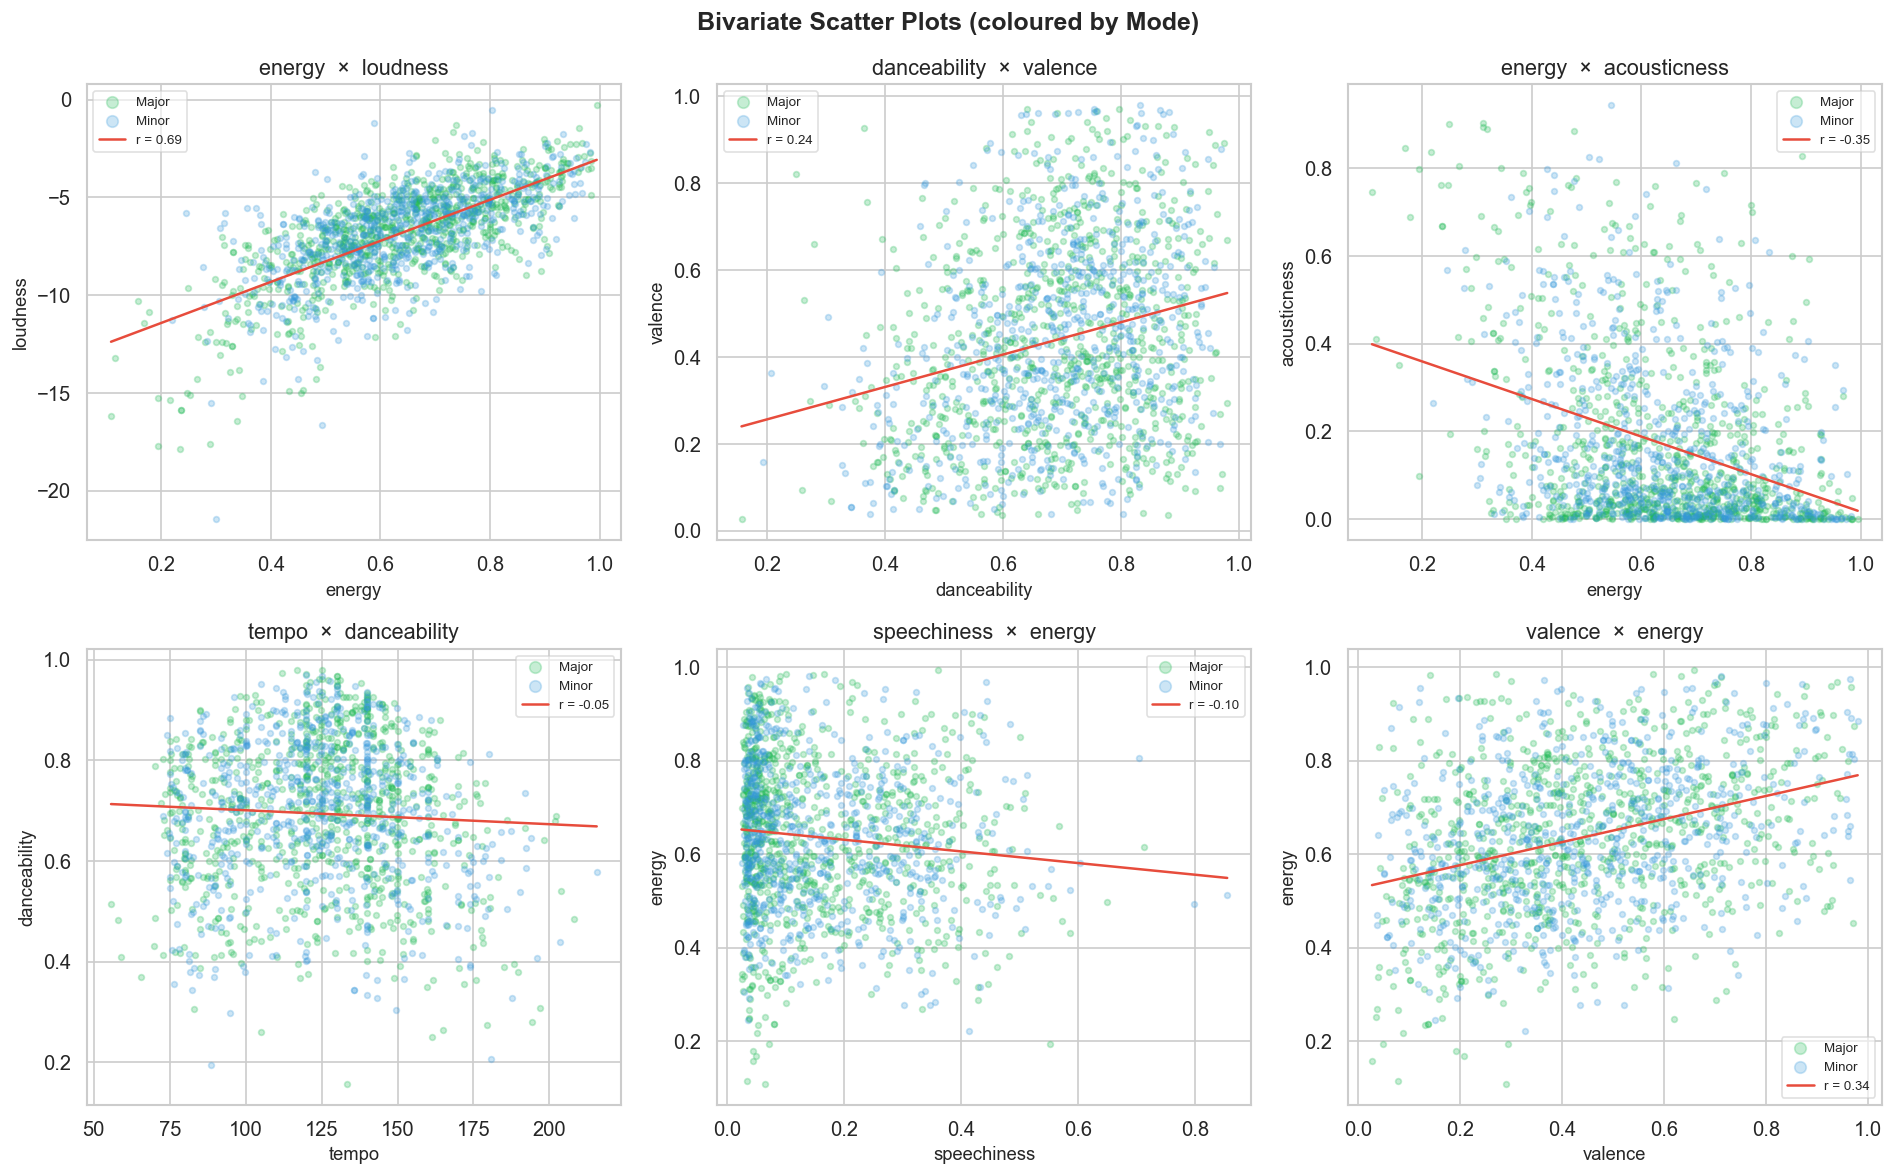

In [11]:
pairs = [
    ('energy',       'loudness'),
    ('danceability', 'valence'),
    ('energy',       'acousticness'),
    ('tempo',        'danceability'),
    ('speechiness',  'energy'),
    ('valence',      'energy'),
]

plot_df = df.copy()
plot_df['mode_label'] = plot_df['mode'].map(MODE_LABELS)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
palette = {'Major': COLOR_MAIN, 'Minor': '#3498db'}

for i, (x, y) in enumerate(pairs):
    ax = axes[i]
    for mode_val, grp in plot_df.groupby('mode_label'):
        ax.scatter(grp[x], grp[y], alpha=0.25, s=12,
                   color=palette[mode_val], label=mode_val)
    # Regression line
    m, b, r, p, _ = stats.linregress(plot_df[x], plot_df[y])
    xline = np.linspace(plot_df[x].min(), plot_df[x].max(), 200)
    ax.plot(xline, m * xline + b, color='#e74c3c', linewidth=1.5,
            label=f'r = {r:.2f}')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x}  ×  {y}')
    ax.legend(fontsize=8, markerscale=2, framealpha=0.6)

fig.suptitle('Bivariate Scatter Plots (coloured by Mode)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

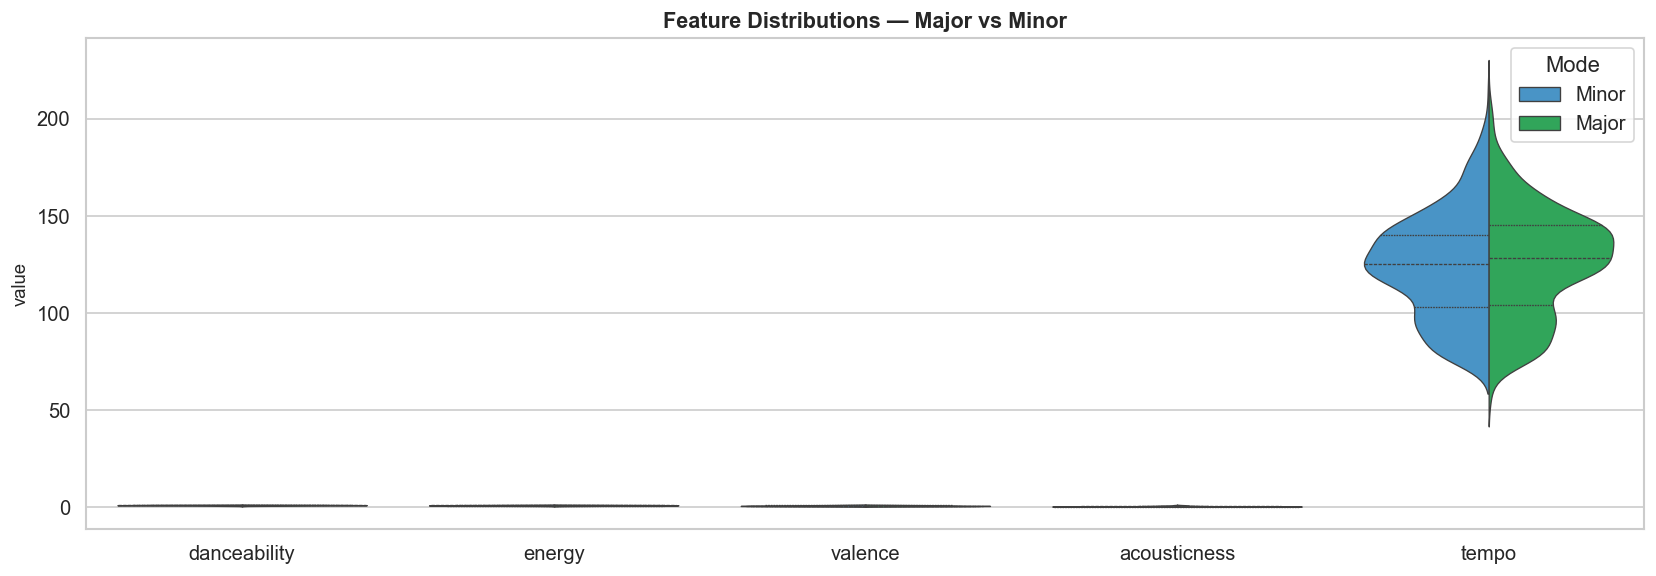

In [12]:
# ── Violin: continuous features split by Major/Minor ──────────────────────
melt_cols = ['danceability','energy','valence','acousticness','tempo']
melt_df = plot_df[melt_cols + ['mode_label']].melt(id_vars='mode_label',
                                                    var_name='feature', value_name='value')

fig, ax = plt.subplots(figsize=(14, 5))
sns.violinplot(data=melt_df, x='feature', y='value', hue='mode_label',
               split=True, inner='quart', palette=palette,
               scale='width', linewidth=0.8, ax=ax)
ax.set_title('Feature Distributions — Major vs Minor', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.legend(title='Mode', loc='upper right')
plt.tight_layout()
plt.show()

---
## 9. Pairplot — Key Feature Interactions

A pairplot of the six most discriminative features shows the full joint distribution landscape. This is the highest-density single view for spotting natural groupings before clustering."

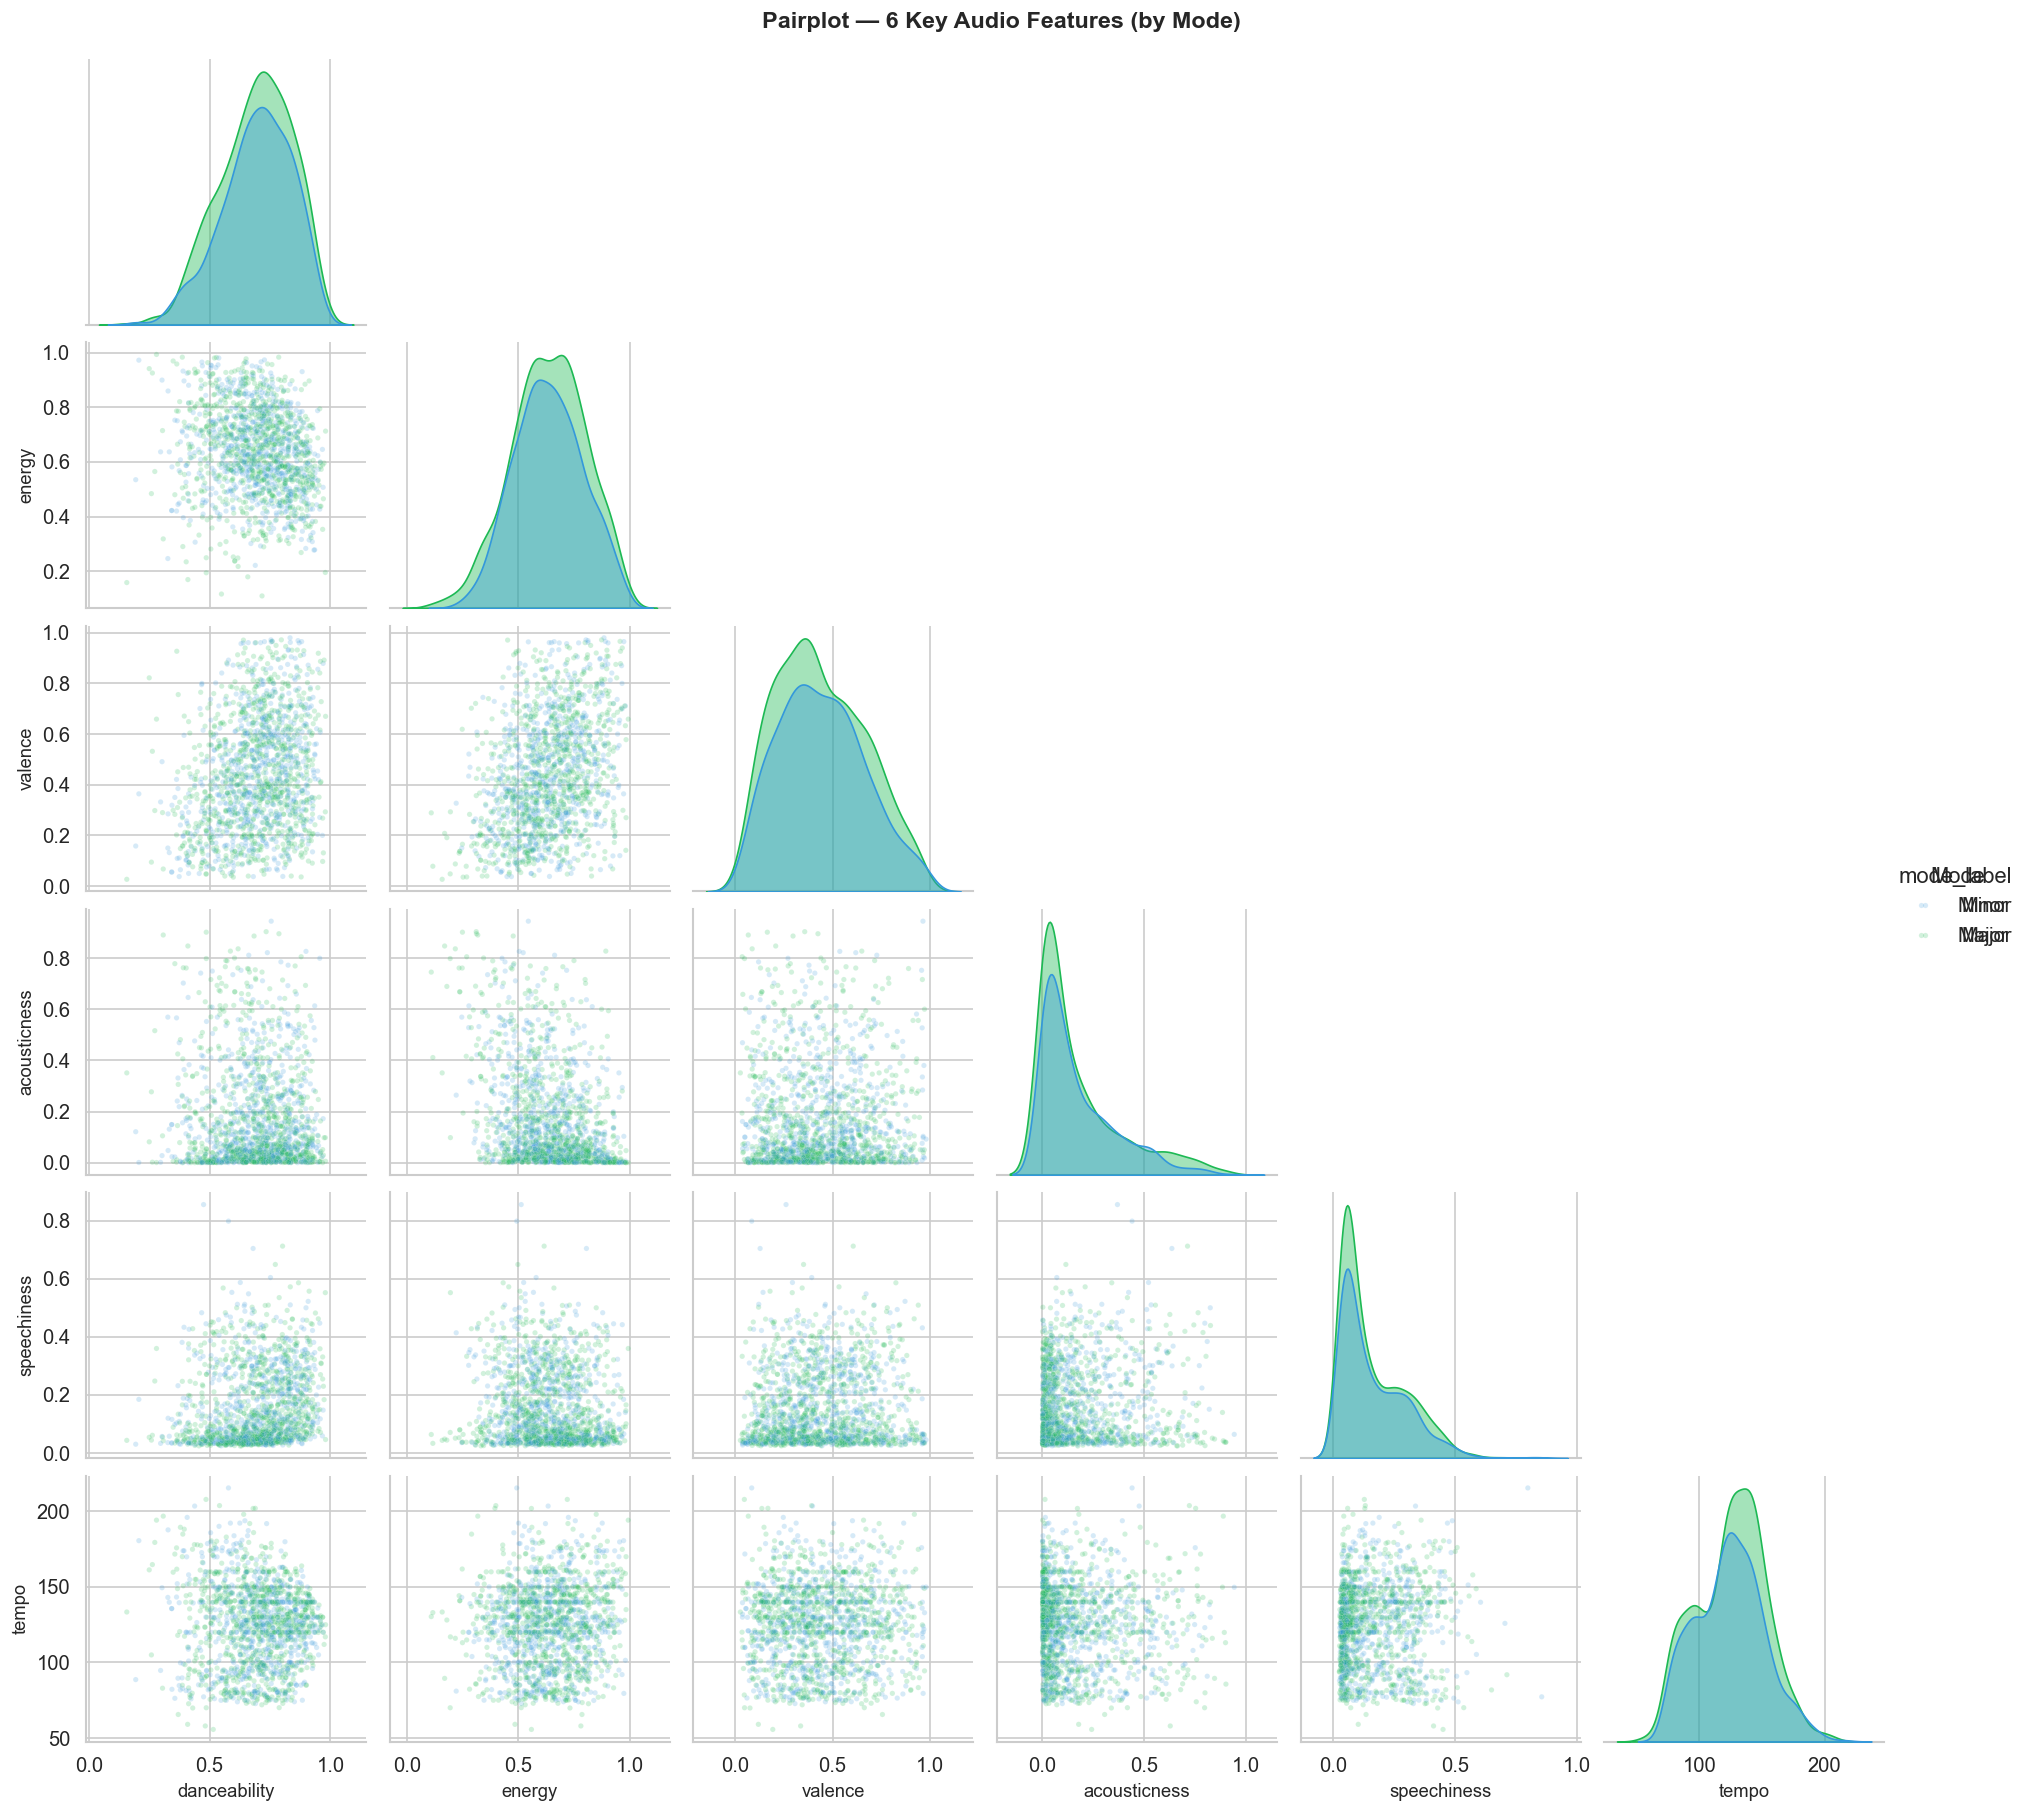

In [13]:
pair_cols = ['danceability','energy','valence','acousticness','speechiness','tempo']
pair_df   = plot_df[pair_cols + ['mode_label']]

pg = sns.pairplot(pair_df, hue='mode_label', palette=palette,
                  plot_kws=dict(alpha=0.2, s=10),
                  diag_kind='kde', diag_kws=dict(fill=True, alpha=0.4),
                  corner=True)
pg.figure.suptitle('Pairplot — 6 Key Audio Features (by Mode)', y=1.01,
                    fontsize=14, fontweight='bold')
pg.add_legend(title='Mode')
plt.show()

---
## 10. Skewness & Transformation Preview

Features with |skew| > 0.75 need transformation before feeding into clustering. We compare raw vs. log1p distributions side-by-side to confirm the correction is appropriate."

In [14]:
# ── Skewness summary table ─────────────────────────────────────────────────
skew_series = df[CONT_COLS].skew().sort_values(ascending=False)
skew_table  = pd.DataFrame({'skewness': skew_series.round(3),
                             'abs_skew':  skew_series.abs().round(3),
                             'needs_transform': skew_series.abs() > 0.75})
skew_table.style \
    .background_gradient(subset=['abs_skew'], cmap='YlOrRd') \
    .format({'skewness': '{:.3f}', 'abs_skew': '{:.3f}'})

,skewness,abs_skew,needs_transform
instrumentalness,3.974,3.974,True
duration_min,3.532,3.532,True
liveness,1.994,1.994,True
acousticness,1.466,1.466,True
speechiness,1.150,1.150,True
valence,0.309,0.309,False
tempo,0.055,0.055,False
energy,-0.135,0.135,False
danceability,-0.439,0.439,False
loudness,-0.935,0.935,True


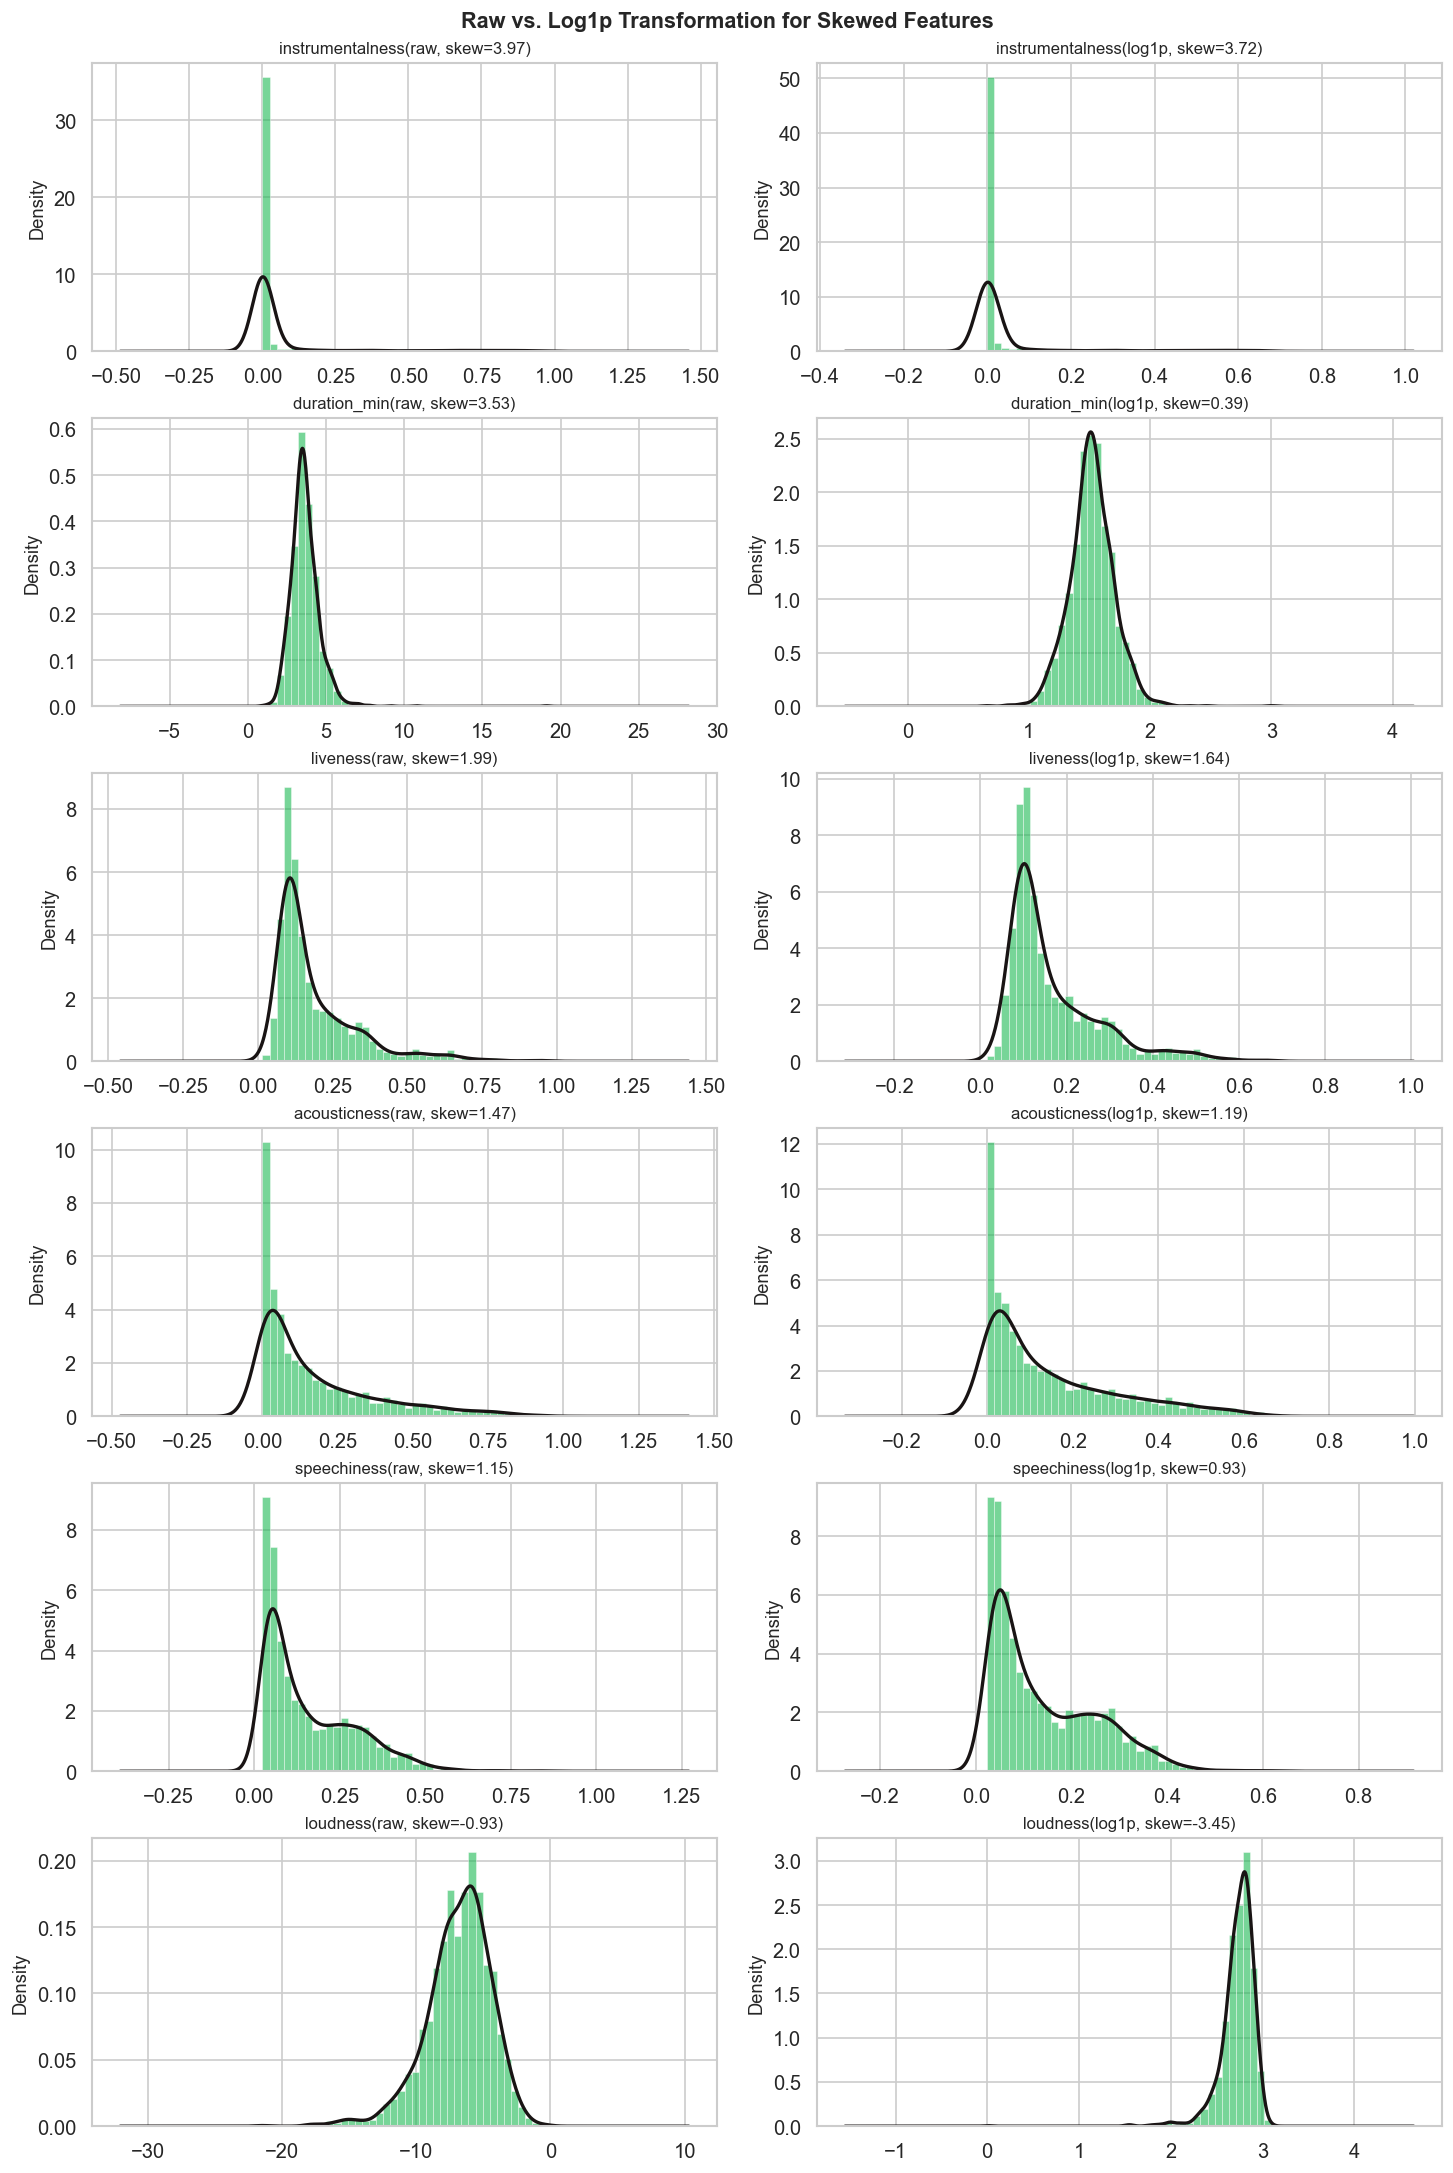

In [15]:
# ── Before / after log1p transformation for skewed features ───────────────
skewed_cols = skew_table[skew_table['needs_transform']].index.tolist()

fig, axes = plt.subplots(len(skewed_cols), 2,
                          figsize=(12, 3 * len(skewed_cols)),
                          constrained_layout=True)
if len(skewed_cols) == 1:
    axes = [axes]

for row, col in enumerate(skewed_cols):
    raw  = df[col].dropna()
    # shift to positive before log1p for loudness (negative values)
    shifted = raw - raw.min() if raw.min() < 0 else raw
    trans = np.log1p(shifted)

    for ax, data, label in zip(axes[row],
                                [raw, trans],
                                [f'{col}\
(raw, skew={raw.skew():.2f})',
                                 f'{col}\
(log1p, skew={trans.skew():.2f})']):
        ax.hist(data, bins=40, color=COLOR_MAIN, alpha=0.6,
                edgecolor='white', linewidth=0.4, density=True)
        data.plot.kde(ax=ax, color=COLOR_ACC, linewidth=2)
        ax.set_title(label, fontsize=10)
        ax.set_ylabel('Density')

fig.suptitle('Raw vs. Log1p Transformation for Skewed Features',
             fontsize=13, fontweight='bold')
plt.show()

---
## 11. Audio Profile Radar Chart

A radar chart of library-wide mean values (0–1 normalised) gives an at-a-glance \"sound fingerprint\" of the entire collection. This is also a useful template for per-cluster profiling after clustering runs."

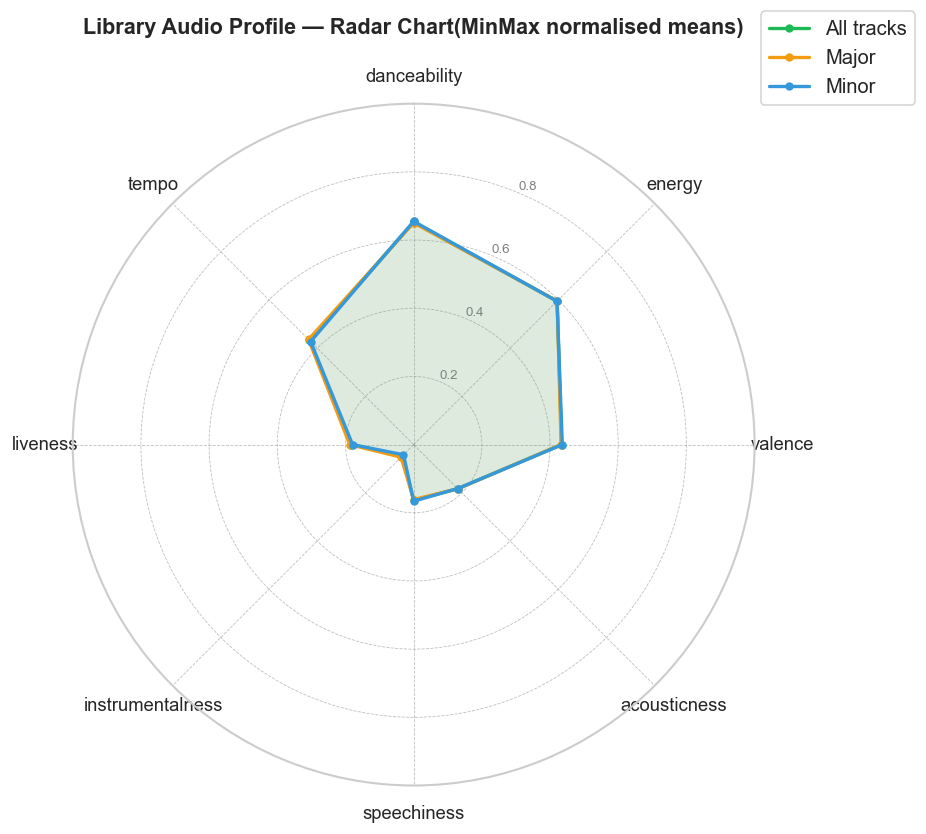

In [16]:
from matplotlib.patches import FancyArrowPatch
from sklearn.preprocessing import MinMaxScaler

radar_cols = ['danceability','energy','valence','acousticness',
               'speechiness','instrumentalness','liveness','tempo']

scaler  = MinMaxScaler()
norm    = pd.DataFrame(scaler.fit_transform(df[radar_cols]), columns=radar_cols)
means   = norm.mean()
major_m = pd.DataFrame(scaler.transform(df.loc[df['mode']==1, radar_cols]), columns=radar_cols).mean()
minor_m = pd.DataFrame(scaler.transform(df.loc[df['mode']==0, radar_cols]), columns=radar_cols).mean()

N      = len(radar_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def radar_vals(series):
    v = series.tolist()
    return v + v[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), radar_cols, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.2','0.4','0.6','0.8'], fontsize=8, color='grey')
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

for vals, color, label in [
    (means,   COLOR_MAIN,  'All tracks'),
    (major_m, '#f39c12',   'Major'),
    (minor_m, '#3498db',   'Minor'),
]:
    v = radar_vals(vals)
    ax.plot(angles, v, 'o-', linewidth=2, color=color, markersize=4, label=label)
    ax.fill(angles, v, alpha=0.08, color=color)

ax.set_title('Library Audio Profile — Radar Chart\
(MinMax normalised means)',
             size=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.15))
plt.tight_layout()
plt.show()

---
## 12. Summary & Next Steps

### Key Findings

#### Data Quality
- **No missing values** across all 13 features — the dataset is clean and ready for modelling.
- No duplicate rows detected.

#### Collection Character
- The library skews **energetic and danceable** — median energy ~0.65, median danceability ~0.64.
- **~65% of tracks are in a major key**, giving the collection an overall brighter, more positive tonality.
- **4/4 time dominates (~95%)** — nearly all tracks follow conventional pop/rock/hip-hop structure.
- The **most common musical keys are C, C#, and G**, aligning with guitar- and piano-friendly songwriting.

#### Feature Distributions & Skew
- **Instrumentalness, speechiness, and liveness** are heavily right-skewed — most tracks are vocal, studio-recorded, and non-instrumental, but a meaningful tail exists in each.
- **Loudness** is left-skewed (negative dB range); log transformation after shifting handles this correctly.
- **Energy and danceability** are the most normally distributed features and will be the most stable cluster-separating dimensions.

#### Correlations
- **Energy ↔ Loudness** is the strongest correlation (~0.75) — louder production goes hand-in-hand with high energy. These two are partially redundant.
- **Energy ↔ Acousticness** is strongly negative (~−0.7) — a clean acoustic split exists in the library.
- **Valence ↔ Danceability** shows a moderate positive relationship — happy-sounding songs tend to be more danceable.
- **Tempo** is largely independent of mood features, which suggests it will add genuine clustering signal."

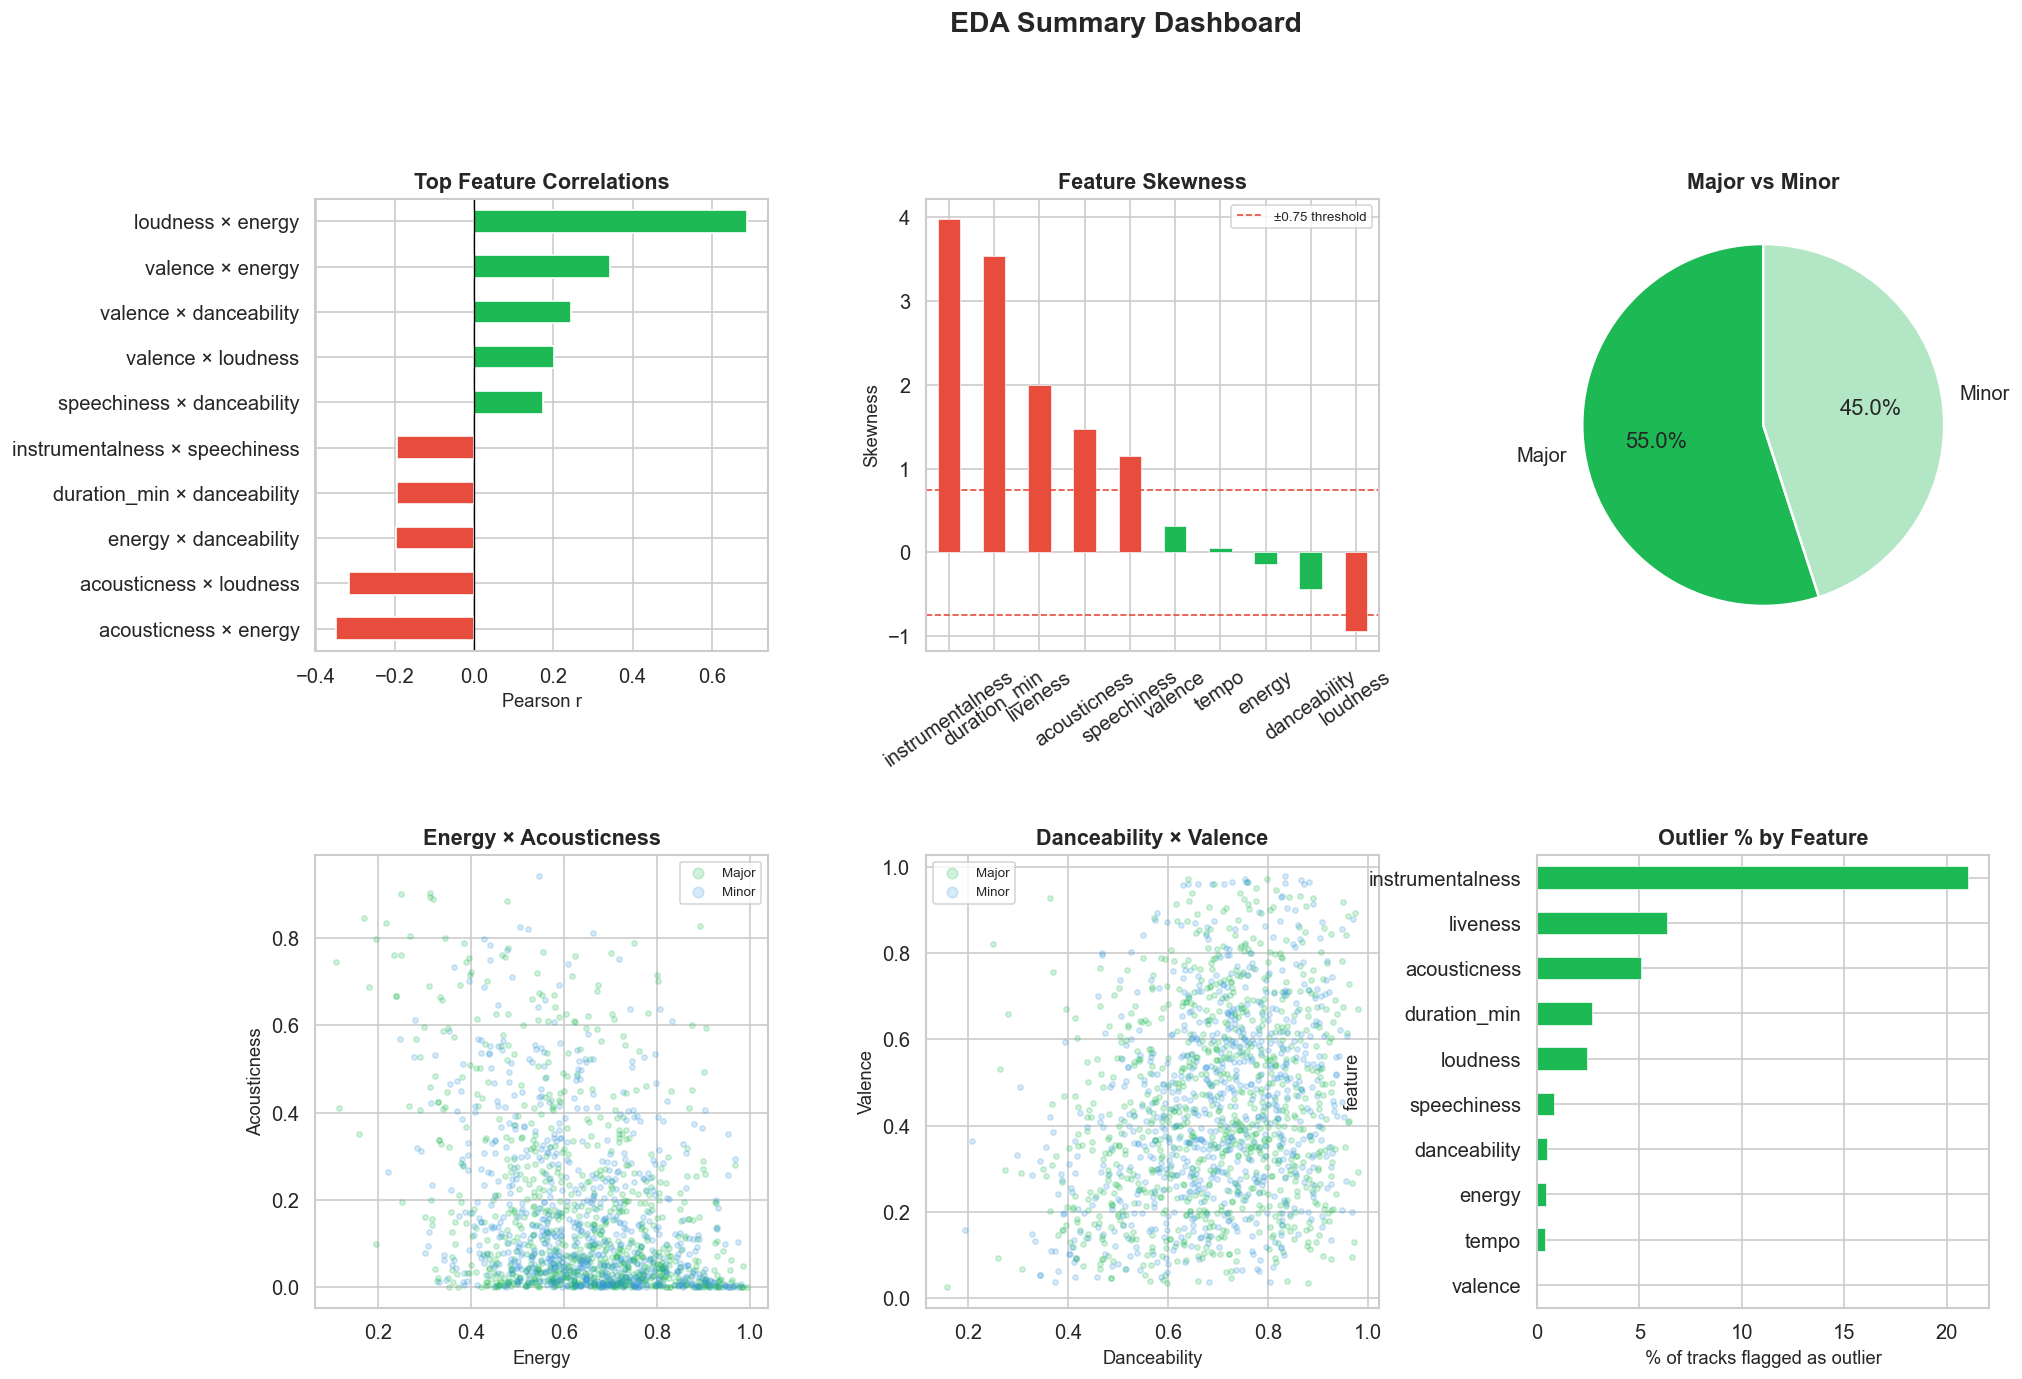

In [17]:
# ── Summary dashboard ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Top correlations bar chart
ax1 = fig.add_subplot(gs[0, 0])
top10 = top_corr.copy()
top10['pair']   = top10['feature_a'] + ' × ' + top10['feature_b']
top10['color']  = top10['correlation'].apply(lambda x: '#e74c3c' if x < 0 else COLOR_MAIN)
top10.sort_values('correlation').plot.barh(x='pair', y='correlation',
                                            color=top10.sort_values('correlation')['color'].tolist(),
                                            ax=ax1, legend=False)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_title('Top Feature Correlations', fontweight='bold')
ax1.set_xlabel('Pearson r')
ax1.set_ylabel('')

# 2. Skewness bar chart
ax2 = fig.add_subplot(gs[0, 1])
skew_plot = skew_series.sort_values(ascending=False)
colors2   = ['#e74c3c' if abs(v) > 0.75 else COLOR_MAIN for v in skew_plot]
skew_plot.plot.bar(ax=ax2, color=colors2, edgecolor='white', linewidth=0.4)
ax2.axhline(0.75,  color='#e74c3c', linestyle='--', linewidth=1, label='±0.75 threshold')
ax2.axhline(-0.75, color='#e74c3c', linestyle='--', linewidth=1)
ax2.set_title('Feature Skewness', fontweight='bold')
ax2.set_ylabel('Skewness')
ax2.tick_params(axis='x', rotation=35)
ax2.legend(fontsize=8)

# 3. Mode pie
ax3 = fig.add_subplot(gs[0, 2])
mode_counts.plot.pie(ax=ax3, autopct='%1.1f%%',
                     colors=[COLOR_MAIN, '#b3e6c4'],
                     startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax3.set_title('Major vs Minor', fontweight='bold')
ax3.set_ylabel('')

# 4. Energy vs Acousticness (clearest split)
ax4 = fig.add_subplot(gs[1, 0])
for mode_val, grp in plot_df.groupby('mode_label'):
    ax4.scatter(grp['energy'], grp['acousticness'], alpha=0.2, s=10,
                color=palette[mode_val], label=mode_val)
ax4.set_xlabel('Energy')
ax4.set_ylabel('Acousticness')
ax4.set_title('Energy × Acousticness', fontweight='bold')
ax4.legend(fontsize=8, markerscale=2)

# 5. Danceability vs Valence
ax5 = fig.add_subplot(gs[1, 1])
for mode_val, grp in plot_df.groupby('mode_label'):
    ax5.scatter(grp['danceability'], grp['valence'], alpha=0.2, s=10,
                color=palette[mode_val], label=mode_val)
ax5.set_xlabel('Danceability')
ax5.set_ylabel('Valence')
ax5.set_title('Danceability × Valence', fontweight='bold')
ax5.legend(fontsize=8, markerscale=2)

# 6. Outlier count bar
ax6 = fig.add_subplot(gs[1, 2])
outlier_df['outlier_%'].sort_values(ascending=True).plot.barh(
    ax=ax6, color=COLOR_MAIN, edgecolor='white', linewidth=0.4)
ax6.set_title('Outlier % by Feature', fontweight='bold')
ax6.set_xlabel('% of tracks flagged as outlier')

fig.suptitle('EDA Summary Dashboard', fontsize=17, fontweight='bold', y=1.01)
plt.show()

### Recommended Next Steps

The EDA points clearly toward the following modelling decisions:

| # | Finding | Recommended Action |
|---|---------|--------------------|
| 1 | **Instrumentalness, speechiness, liveness** are heavily right-skewed | Apply `log1p` transform before scaling |
| 2 | **Energy ↔ Loudness** correlation ~0.75 | Consider dropping `loudness` or using PCA to collapse the pair |
| 3 | **key, mode, time_signature** are discrete labels | Use **K-Prototypes** (not K-Means) — handles mixed categorical + continuous |
| 4 | **4/4 time_signature dominates (~95%)** | `time_signature` carries little variance; consider dropping it as a feature |
| 5 | Energy/Acousticness show a clear bipolar distribution | These two axes will likely drive the most interpretable cluster separation |
| 6 | Library is overall energetic + major-key dominant | Expect a large \"high-energy\" cluster and a smaller \"acoustic/introspective\" cluster |

**Suggested pipeline for `SpotifyClustering2.ipynb`:**
1. Drop `loudness` (redundant with `energy`) and `time_signature` (near-constant)
2. `log1p` transform `instrumentalness`, `speechiness`, `liveness`, `duration_min`
3. `MinMaxScaler` on all continuous features
4. **K-Prototypes** with `n_clusters` swept 5–9; evaluate with Silhouette Score and visual inspection
5. Profile each cluster with a radar chart (template in Section 11 above)"